# Strategy Analysis - FX Pairs

This notebook reads back the selection made from the immutable validation candidate set and the
holdout lineage that selection determines, and assesses both. Selection uses validation backtest
Sharpe with the backtest identity as the deterministic tie-breaker. Cost sensitivity is excluded
from selection, and nothing measured on the holdout can revise the choice - not because a lock
forbids it, but because the choice was made upstream against a set that is already frozen.

The holdout results are produced by `17_holdout_predictions` and `18_holdout_backtest`. This
notebook writes nothing; it fails if either is missing rather than producing them itself, so
reading the holdout and deciding what to run against it stay separate acts.

**Learning objectives**

- Reproduce validation selection from an immutable, complete candidate set.
- Verify that the holdout lineage on record is the one the selection determines.
- Interpret cost and risk variants through controlled sibling comparisons.
- Assess validation and holdout performance with interval and paired evidence.

**Book reference**: Chapters 16-20

**Prerequisites**: `17_holdout_predictions` and `18_holdout_backtest`, and the candidate set
`15_risk_management` freezes.

In [1]:
"""Read back the selected FX validation lineage and its holdout, and assess both."""

import json
import sqlite3
import warnings
from collections import Counter
from copy import deepcopy
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import polars as pl
import yaml

from case_studies.research import (
    BacktestResult,
    CandidateSet,
    OfficialPopulation,
    PredictionResult,
    Result,
    TrainingResult,
    open_study,
)
from case_studies.research.holdout import build_holdout_training_spec
from case_studies.research.population import superseded_members_at
from case_studies.research.strategy import strategy_warmup_periods
from case_studies.utils.artifact_digest import value_digest
from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import cost_view, ensure_backtest_spec
from case_studies.utils.backtest_runner import resolved_allow_short_selling
from case_studies.utils.cohort_metrics import compute_and_register
from case_studies.utils.paired_metrics import populate_paired_metrics
from case_studies.utils.registry import (
    backtest_run_status,
    load_backtest_metrics,
    load_paired_metrics,
)
from case_studies.utils.registry.specs import training_hash_from_spec
from case_studies.utils.strategy_analysis import (
    resolve_canonical_rank1_lineage,
    resolve_solvent_carrier,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS

In [2]:
CASE_STUDY_ID = "fx_pairs"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
CANDIDATE_SET_NAME = "fx_pairs:holdout-candidates"

## Resolve the carrier and its holdout lineage

Selection is not a parameter and is not made here. `resolve_solvent_carrier` reads the
highest-Sharpe registered validation backtest across the baseline, allocation and risk-overlay
stages, among runs that stayed solvent and belong to a generation still in force. Cost
siblings are not candidates: a cost variant is a descendant of a selection rather than an
entrant in one. Nothing on this page can revise the choice.

The holdout lineage is matched to that carrier by CONFIGURATION - family, configuration name,
label and checkpoint - rather than by the validation model's training hash. A genuine retrain
does not share that hash; that is what makes it a retrain, and a lineage query keyed on it can
only ever find a validation fit scored over a later window.

There is no lock and no ledger. The whole rule is: take the configuration validation ranked
first, retrain it on everything up to the holdout window, predict, and run that same backtest
configuration on the result. An earlier design pre-registered the lineage in a research lock,
which made the holdout a one-shot transaction and therefore impossible to correct - any fix
upstream needed a retrain the lock forbade, and the lock could not be reissued.

In [3]:
study = open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

# The carrier is the highest-Sharpe registered validation backtest across the baseline,
# allocation and risk-overlay stages, among runs that stayed solvent and belong to a generation
# still in force. Read from the registry, so this page cannot report a configuration the
# validation stages did not rank first.
# The frozen set is the field, exactly as in `17` and `18`. This page reports the carrier as the
# case study's answer, so it resolves over the same restricted field rather than over the whole
# registry - otherwise a row the set never admitted could still move the common-support
# intersection and change which admitted row is reported.
holdout_candidates = CandidateSet.one(study, name=CANDIDATE_SET_NAME)
ADMITTED = frozenset(holdout_candidates.members)
# The prediction sets behind the admitted backtests. `compute_and_register` scopes cohorts by
# prediction rather than by backtest, and left unscoped it computes the effective trial count and
# the deflated Sharpe over the whole registry - every retired generation and every configuration
# no population publishes included. K is what the deflation divides by, so an unscoped call
# reports a correction computed over a population this page does not describe.
with sqlite3.connect(str(get_case_study_dir(CASE_STUDY_ID) / "run_log" / "registry.db")) as _con:
    ADMITTED_PREDICTIONS = [
        row[0]
        for row in _con.execute(
            "SELECT DISTINCT prediction_hash FROM backtest_runs "
            f"WHERE backtest_hash IN ({','.join('?' * len(ADMITTED))})",
            tuple(sorted(ADMITTED)),
        )
    ]
carrier = resolve_solvent_carrier(CASE_STUDY_ID, admitted=ADMITTED)

selected_validation = study.results.open(str(carrier["val_backtest_hash"]))
selected_prediction = study.results.open(str(carrier["val_prediction_hash"]))
selected_training = study.results.open(str(carrier["training_hash"]))
selected_record = selected_validation.registry_record()
selected_prediction_record = selected_prediction.registry_record()
selected_training_record = selected_training.registry_record()
selected_training_spec = selected_training.spec()
selected_computation = selected_training_spec.get("computation", selected_training_spec)

# Everything this case study backtested on validation and still publishes: the equal-weight
# baselines, the allocation variants and the risk overlays. Cost siblings are excluded, because
# a cost variant is a descendant of a selection rather than a candidate for one. Superseded
# generations are excluded for the same reason the carrier resolution excludes them - a retired
# row still ranks, and a distribution that mixes two generations answers no question.
_retired = superseded_members_at(study.root, member_kind="backtest")
candidate_rows_source = (
    study.backtests.table()
    .filter(
        (pl.col("split") == "validation")
        & (pl.col("execution_tier") == "canonical")
        & pl.col("complete")
        & pl.col("stage").is_in(["signal", "allocation", "risk_overlay"])
        & pl.col("sharpe").is_not_null()
        & ~pl.col("backtest_hash").is_in(list(_retired))
        # Restricted to the frozen set, because this is the distribution the selection was
        # made from and the selection sees exactly this field. A table drawn from a wider one
        # invites the reader to compare the carrier against rows it was never ranked against.
        & pl.col("backtest_hash").is_in(list(ADMITTED))
    )
    .sort("sharpe", "backtest_hash", descending=[True, False])
)

pl.DataFrame(
    {
        "field": ["carrier backtest", "carrier stage", "candidates ranked", "validation Sharpe"],
        "value": [
            selected_validation.hash,
            str(carrier["val_stage"]),
            str(candidate_rows_source.height),
            f"{carrier['val_sharpe']:.4f}",
        ],
    }
)

field,value
str,str
"""carrier backtest""","""56070f34dff1"""
"""carrier stage""","""risk_overlay"""
"""candidates ranked""","""1794"""
"""validation Sharpe""","""0.2639"""


## The selected validation lineage

Model family, configuration, label, checkpoint and the data artifacts the fit read are printed
together, because they are what the holdout comparison holds fixed. The provenance fields are
checked rather than displayed: a selected training run with no recorded source commit or runtime
cannot be reproduced by a reader, and a holdout number from a run nobody can reproduce is not
evidence of anything.

In [4]:
for field in ("label_artifact", "feature_artifacts", "cv"):
    if not selected_computation.get(field):
        raise ValueError(f"the selected training run records no {field}")
if not selected_training_record.get("git_commit"):
    raise ValueError("the selected training run records no source commit")
if not json.loads(selected_training_record.get("runtime_json") or "{}"):
    raise ValueError("the selected training run records no runtime provenance")

selected_identity = pl.DataFrame(
    {
        "field": [
            "label",
            "family",
            "configuration",
            "checkpoint kind",
            "checkpoint value",
            "training hash",
            "prediction hash",
            "validation backtest hash",
            "source commit",
        ],
        "value": [
            str(selected_training_spec["label"]),
            str(selected_training_spec["family"]),
            str(selected_training_spec["config_name"]),
            str(selected_prediction_record["checkpoint_kind"]),
            str(selected_prediction_record["checkpoint_value"]),
            selected_training.hash,
            selected_prediction.hash,
            selected_validation.hash,
            str(selected_training_record["git_commit"]),
        ],
    }
)
selected_identity

field,value
str,str
"""label""","""fwd_ret_21d"""
"""family""","""deep_learning"""
"""configuration""","""tcn"""
"""checkpoint kind""","""epoch"""
"""checkpoint value""","""35"""
"""training hash""","""47fc728b2ef4"""
"""prediction hash""","""9eb5f506a0ee"""
"""validation backtest hash""","""56070f34dff1"""
"""source commit""","""19b5193c"""


## Validation candidate evidence

Every candidate remains visible below. The displayed order reproduces the selection rule; IC and
every metric other than Sharpe remain descriptive.

In [5]:


def _metric_row(result: BacktestResult) -> dict[str, Any]:
    metrics = load_backtest_metrics(
        CASE_STUDY_ID,
        backtest_hash=result.hash,
        case_dir=study.root,
    )
    if metrics.height != 1:
        raise ValueError(f"backtest {result.hash} has {metrics.height} metric rows")
    return metrics.row(0, named=True)


candidate_rows = []
for member_hash in candidate_rows_source.get_column("backtest_hash").to_list():
    result = Result.open(study, member_hash)
    if not isinstance(result, BacktestResult) or not result.complete:
        raise ValueError(f"candidate {member_hash} is not a complete backtest")
    record = result.registry_record()
    lineage = result.lineage()
    training = lineage["training_spec"]
    prediction = Result.open(study, record["prediction_hash"])
    if not isinstance(prediction, PredictionResult):
        raise TypeError(f"candidate {member_hash} does not reference a prediction")
    prediction_record = prediction.registry_record()
    metric = _metric_row(result)
    if record["stage"] not in {"signal", "allocation", "risk_overlay"}:
        raise ValueError(f"candidate {member_hash} has an ineligible stage")
    if any(metric.get(name) is None for name in ("sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi")):
        raise ValueError(f"candidate {member_hash} lacks Sharpe interval evidence")
    candidate_rows.append(
        {
            "backtest_hash": result.hash,
            "prediction_hash": record["prediction_hash"],
            "stage": record["stage"],
            "label": training["label"],
            "family": training["family"],
            "config_name": training["config_name"],
            "checkpoint_kind": prediction_record["checkpoint_kind"],
            "checkpoint_value": prediction_record["checkpoint_value"],
            "sharpe": metric["sharpe"],
            "sharpe_ci95_lo": metric["sharpe_ci95_lo"],
            "sharpe_ci95_hi": metric["sharpe_ci95_hi"],
        }
    )

# Sorted on raw Sharpe, which is not how the carrier was chosen: with a conformal candidate in
# the field the resolver re-ranks everything on the timestamps they all share, and it can return
# a row that is not first here. The two agree on this case study and the check says so rather
# than assuming it. A disagreement is a refusal and not a re-ordering, because the honest table
# is the one whose top row is the result the page goes on to report - and if raw Sharpe stops
# producing that row, what to display instead is a decision, not a repair.
candidate_evidence = pl.DataFrame(candidate_rows).sort(
    ["sharpe", "backtest_hash"], descending=[True, False]
)
if candidate_evidence["backtest_hash"][0] != selected_validation.hash:
    raise ValueError(
        f"the displayed candidate distribution ranks {candidate_evidence['backtest_hash'][0]} "
        f"first on raw Sharpe, but the carrier is {selected_validation.hash}. The canonical "
        "resolver re-ranked the field on common support; the table and the selection would "
        "describe different results."
    )
candidate_evidence

backtest_hash,prediction_hash,stage,label,family,config_name,checkpoint_kind,checkpoint_value,sharpe,sharpe_ci95_lo,sharpe_ci95_hi
str,str,str,str,str,str,str,i64,f64,f64,f64
"""56070f34dff1""","""9eb5f506a0ee""","""risk_overlay""","""fwd_ret_21d""","""deep_learning""","""tcn""","""epoch""",35,0.263914,-0.413466,0.884329
"""9402978117e9""","""9eb5f506a0ee""","""allocation""","""fwd_ret_21d""","""deep_learning""","""tcn""","""epoch""",35,0.263914,-0.413466,0.884329
"""747e7e47abaa""","""a9b0e4416d41""","""allocation""","""fwd_ret_21d""","""linear""","""ridge_a1000000.0""","""final""",null,0.229783,-0.384729,0.874633
"""bb67756a76f0""","""9eb5f506a0ee""","""risk_overlay""","""fwd_ret_21d""","""deep_learning""","""tcn""","""epoch""",35,0.218261,-0.458083,0.840982
"""d01eb8ff5ef5""","""9eb5f506a0ee""","""signal""","""fwd_ret_21d""","""deep_learning""","""tcn""","""epoch""",35,0.209738,-0.386645,0.813544
…,…,…,…,…,…,…,…,…,…,…
"""a6191b785c6e""","""438051386bcc""","""signal""","""fwd_ret_1d""","""gbm""","""default_mae""","""iteration""",150,-2.658264,-3.389268,-2.029751
"""b159c312cb0c""","""a58ac5f3bc76""","""signal""","""fwd_ret_1d""","""gbm""","""default_huber""","""iteration""",200,-2.685904,-3.440803,-2.081846
"""b6ac0e5e3e21""","""2a21cd66504b""","""signal""","""fwd_ret_1d""","""gbm""","""default_mae""","""iteration""",200,-2.693281,-3.420676,-2.082155


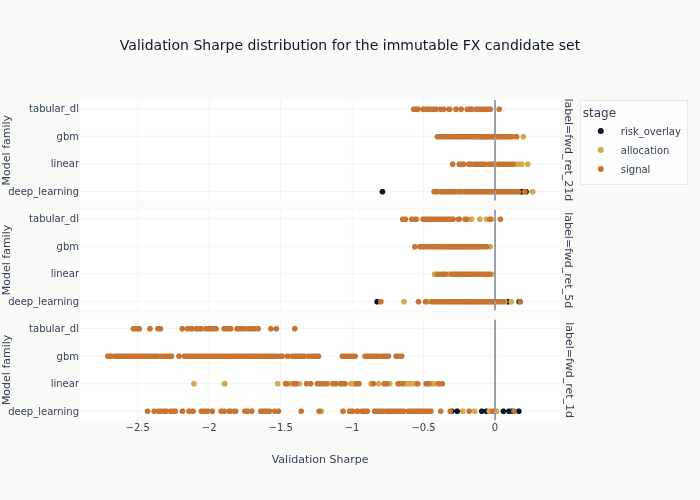

In [6]:
candidate_figure = px.scatter(
    candidate_evidence,
    x="sharpe",
    y="family",
    color="stage",
    facet_row="label",
    hover_data=["config_name", "backtest_hash"],
    title="Validation Sharpe distribution for the immutable FX candidate set",
    labels={"sharpe": "Validation Sharpe", "family": "Model family"},
)
candidate_figure.add_vline(x=0, line_dash="dot", line_color=COLORS["recede"])
candidate_figure.show()

## Controlled cost and risk comparisons

Cost sensitivity and risk overlays are read from their official populations. A sibling enters a
comparison only when its prediction, signal, allocation, rebalance, execution, and price identity
match the selected lineage after removing the field being varied.

In [7]:


def _comparison_projection(
    result: BacktestResult,
    *,
    omit_costs: bool,
    omit_risk: bool,
) -> dict[str, Any]:
    projected = deepcopy(result.spec())
    projected.pop("chapter", None)
    projected.pop("_runtime_backtest_config", None)
    if omit_risk:
        projected.get("strategy", {}).pop("risk", None)
    metadata = projected.get("backtest_config", {}).get("metadata")
    if isinstance(metadata, dict):
        metadata.pop("chapter", None)
    if omit_costs:
        config = projected.get("backtest_config", {})
        config.pop("commission", None)
        config.pop("slippage", None)
    return {
        "prediction_hash": result.registry_record()["prediction_hash"],
        "spec": projected,
    }


cost_population = OfficialPopulation.one(study, name=f"{CASE_STUDY_ID}:cost-sensitivity-backtests")
risk_population = OfficialPopulation.one(study, name=f"{CASE_STUDY_ID}:risk-overlay-backtests")
cost_population.require_complete()
risk_population.require_complete()

selected_cost_core = _comparison_projection(selected_validation, omit_costs=True, omit_risk=True)
selected_risk_core = _comparison_projection(selected_validation, omit_costs=False, omit_risk=True)

cost_rows = []
for member_hash in cost_population.members:
    result = Result.open(study, member_hash)
    if not isinstance(result, BacktestResult):
        raise TypeError("cost population contains a non-backtest result")
    if _comparison_projection(result, omit_costs=True, omit_risk=True) != selected_cost_core:
        continue
    costs = cost_view(result.spec())
    metric = _metric_row(result)
    if any(metric.get(name) is None for name in ("sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi")):
        raise ValueError(f"cost sibling {result.hash} lacks Sharpe interval evidence")
    cost_rows.append(
        {
            "total_cost_bps": costs["commission_bps"] + costs["slippage_bps"],
            "sharpe": metric["sharpe"],
            "sharpe_ci95_lo": metric["sharpe_ci95_lo"],
            "sharpe_ci95_hi": metric["sharpe_ci95_hi"],
            "backtest_hash": result.hash,
        }
    )
if not cost_rows:
    raise ValueError("no controlled cost siblings match the selected strategy")
cost_evidence = pl.DataFrame(cost_rows).sort("total_cost_bps")
cost_evidence

total_cost_bps,sharpe,sharpe_ci95_lo,sharpe_ci95_hi,backtest_hash
f64,f64,f64,f64,str
0.0,0.412505,-0.252368,1.023592,"""06839879d213"""
1.0,0.390283,-0.276707,1.001122,"""c51af7ce1d07"""
2.0,0.37028,-0.297894,0.982264,"""def5aafffcf9"""
3.0,0.347635,-0.321878,0.96076,"""c6b41b785e46"""
5.0,0.306495,-0.370493,0.922672,"""dba0d6fa3912"""
…,…,…,…,…
10.0,0.199603,-0.483393,0.825249,"""2d257b0fc762"""
15.0,0.092826,-0.592249,0.725548,"""4928539fb0e6"""
20.0,-0.015086,-0.707478,0.621127,"""efcf2c486ff0"""


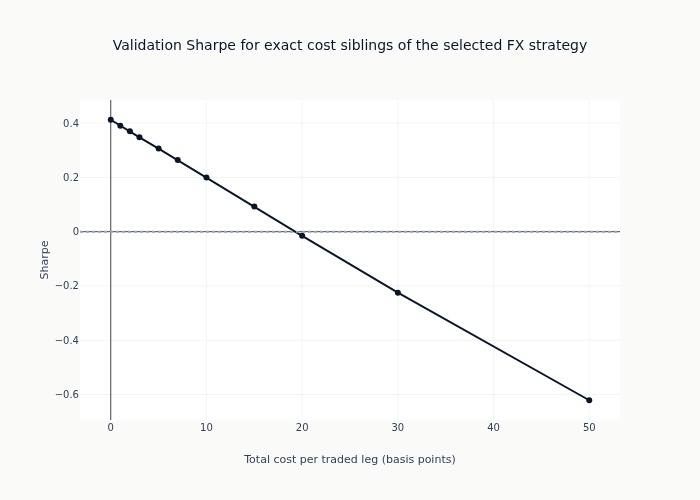

In [8]:
cost_figure = px.line(
    cost_evidence,
    x="total_cost_bps",
    y="sharpe",
    markers=True,
    title="Validation Sharpe for exact cost siblings of the selected FX strategy",
    labels={"total_cost_bps": "Total cost per traded leg (basis points)", "sharpe": "Sharpe"},
)
cost_figure.add_hline(y=0, line_dash="dot", line_color=COLORS["recede"])
cost_figure.show()

In [9]:
risk_rows = []
for member_hash in risk_population.members:
    result = Result.open(study, member_hash)
    if not isinstance(result, BacktestResult):
        raise TypeError("risk population contains a non-backtest result")
    if _comparison_projection(result, omit_costs=False, omit_risk=True) != selected_risk_core:
        continue
    metric = _metric_row(result)
    if any(metric.get(name) is None for name in ("sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi")):
        raise ValueError(f"risk sibling {result.hash} lacks Sharpe interval evidence")
    risk = result.spec()["strategy"]["risk"]
    risk_rows.append(
        {
            "risk_name": risk["name"],
            "sharpe": metric["sharpe"],
            "sharpe_ci95_lo": metric["sharpe_ci95_lo"],
            "sharpe_ci95_hi": metric["sharpe_ci95_hi"],
            "backtest_hash": result.hash,
        }
    )
if not risk_rows:
    raise ValueError("no controlled risk siblings match the selected strategy")
risk_evidence = pl.DataFrame(risk_rows).sort("sharpe", descending=True)
risk_evidence

risk_name,sharpe,sharpe_ci95_lo,sharpe_ci95_hi,backtest_hash
str,f64,f64,f64,str
"""trailing_20pct""",0.263914,-0.413466,0.884329,"""56070f34dff1"""
"""stop_loss_15pct""",0.218261,-0.458083,0.840982,"""bb67756a76f0"""
"""time_exit_10""",0.208248,-0.511933,0.813404,"""354a0cfdf5f0"""
"""time_exit_40""",0.205973,-0.437391,0.820456,"""b54273fc9934"""
"""time_exit_20""",0.205766,-0.481616,0.838653,"""40aba153ce15"""
…,…,…,…,…
"""trailing_5pct""",0.148676,-0.587132,0.814224,"""ab5e7406846a"""
"""stop_loss_3pct""",-0.056528,-0.808164,0.623685,"""51093c7e4239"""
"""trailing_3pct""",-0.061602,-0.811356,0.583424,"""e324b6451fab"""


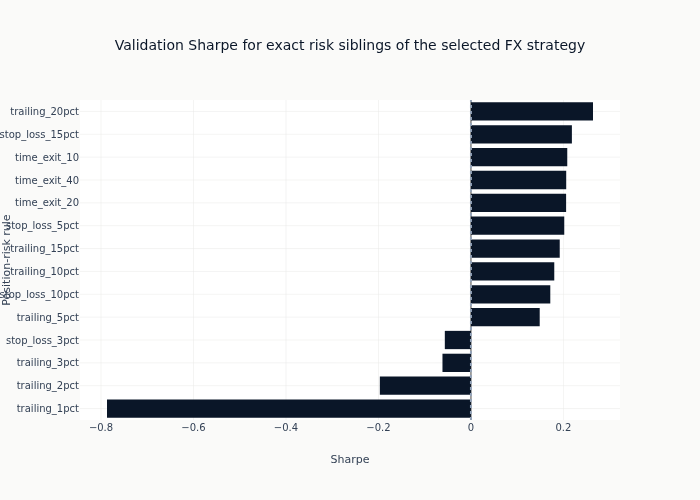

In [10]:
risk_figure = px.bar(
    risk_evidence.sort("sharpe"),
    x="sharpe",
    y="risk_name",
    orientation="h",
    title="Validation Sharpe for exact risk siblings of the selected FX strategy",
    labels={"sharpe": "Sharpe", "risk_name": "Position-risk rule"},
)
risk_figure.add_vline(x=0, line_dash="dot", line_color=COLORS["recede"])
risk_figure.show()

The cost curve is allowed to be monotone, nonmonotone, entirely positive, or entirely negative.
The computed summary reports the observed shape without requiring a crossing. Risk rows are ordered
descriptively and do not replace the candidate-set selection rule.

In [11]:
cost_differences = cost_evidence.get_column("sharpe").diff().drop_nulls()
if (cost_differences < 0).all():
    cost_shape = "strictly decreasing over the declared grid"
elif (cost_differences <= 0).all():
    cost_shape = "nonincreasing over the declared grid"
else:
    cost_shape = "nonmonotone over the declared grid"

if (cost_evidence.get_column("sharpe") > 0).all():
    sign_summary = "all observed Sharpe estimates are positive"
elif (cost_evidence.get_column("sharpe") < 0).all():
    sign_summary = "all observed Sharpe estimates are negative"
else:
    sign_summary = "the observed Sharpe estimates include both signs or zero"

controlled_summary = pl.DataFrame(
    {
        "comparison": ["cost sensitivity", "position-risk controls"],
        "finding": [
            f"Sharpe is {cost_shape}; {sign_summary}.",
            (
                f"The highest point estimate belongs to {risk_evidence['risk_name'][0]}; "
                "the interval columns determine whether that ordering is resolved."
            ),
        ],
    }
)
controlled_summary

comparison,finding
str,str
"""cost sensitivity""","""Sharpe is strictly decreasing …"
"""position-risk controls""","""The highest point estimate bel…"


## Require the holdout lineage the carrier determines

The holdout results are not whatever happens to carry the holdout split; they are required to
be the ones this carrier determines. The match is not on the carrier's own training hash - a
genuine retrain never shares the validation model's training identity, which is the whole
point of a retrain - and it is not on family, configuration name and label either, because
several training specifications carry the same three names. The holdout training identity is
derived here the way `17_holdout_predictions` derives it, and the query asks for that hash.

In [12]:
_carrier_ck = selected_prediction_record["checkpoint_kind"]
_carrier_cv = selected_prediction_record["checkpoint_value"]
_observation_timeline = (
    pl.read_parquet(study.root / "labels" / f"{carrier['label']}.parquet")
    .get_column("timestamp")
    .unique()
    .sort()
    .to_list()
)
EXPECTED_HOLDOUT_TRAINING_HASH = training_hash_from_spec(
    build_holdout_training_spec(
        study,
        study.results.open(carrier["training_hash"]).spec(),
        timeline=_observation_timeline,
        case_study=CASE_STUDY_ID,
    )
)
with sqlite3.connect(str(study.root / "run_log" / "registry.db")) as _conn:
    _holdout_rows = _conn.execute(
        """
        SELECT prediction_hash
        FROM prediction_sets
        WHERE split = 'holdout'
          AND training_hash = ?
          AND checkpoint_kind IS ? AND checkpoint_value IS ?
        ORDER BY prediction_hash
        """,
        (EXPECTED_HOLDOUT_TRAINING_HASH, _carrier_ck, _carrier_cv),
    ).fetchall()
if len(_holdout_rows) != 1:
    raise ValueError(
        f"holdout training run {EXPECTED_HOLDOUT_TRAINING_HASH} resolves "
        f"{len(_holdout_rows)} prediction sets at checkpoint {_carrier_ck}={_carrier_cv}; "
        "exactly one is required - run 17_holdout_predictions, or delete the superseded one"
    )
holdout_prediction = Result.open(study, _holdout_rows[0][0])

_holdout_backtests = (
    study.backtests.table()
    .filter((pl.col("prediction_hash") == holdout_prediction.hash) & pl.col("complete"))
    .get_column("backtest_hash")
    .to_list()
)
if len(_holdout_backtests) != 1:
    raise ValueError(
        f"holdout prediction {holdout_prediction.hash} has {len(_holdout_backtests)} complete "
        "backtests; exactly one is required - run 18_holdout_backtest"
    )
holdout_backtest = Result.open(study, _holdout_backtests[0])

# One complete backtest on the holdout prediction is not the same as the carrier's replay
# having been the one that produced it, and comparing the `strategy` block alone does not
# close the gap: commissions, slippage, account settings and the price identity all sit
# outside that block, so a cost variant or a stale-price run registered against the same
# prediction set would pass a strategy comparison and be reported as the carrier's holdout.
#
# The backtest hash covers every input that changes the result, by construction. So the
# expected specification is rebuilt here exactly as `18_holdout_backtest` builds it - the
# carrier's registered spec, the holdout prediction, the holdout price frame with the
# strategy's declared warmup, and the digest of that frame - and the registered backtest is
# required to BE that identity rather than to resemble it.
_holdout_prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    str(carrier["label"]),
    split="holdout",
    warmup_periods=strategy_warmup_periods(json.loads(selected_record["spec_json"])),
)
_expected_spec = ensure_backtest_spec(
    CASE_STUDY_ID,
    get_backtest_config(CASE_STUDY_ID),
    json.loads(selected_record["spec_json"]),
    prices=_holdout_prices,
    prediction_hash=holdout_prediction.hash,
    initial_cash=get_backtest_config(CASE_STUDY_ID).initial_cash,
)
_expected_spec["chapter"] = "ch20"
_expected_spec.setdefault("input_identity", {})["prices"] = value_digest(_holdout_prices)
_expected_spec["backtest_config"]["account"]["allow_short_selling"] = resolved_allow_short_selling(
    _expected_spec, None
)
EXPECTED_HOLDOUT_BACKTEST_HASH = backtest_run_status(
    CASE_STUDY_ID, holdout_prediction.hash, _expected_spec
).backtest_hash
if holdout_backtest.hash != EXPECTED_HOLDOUT_BACKTEST_HASH:
    raise ValueError(
        f"the registered holdout backtest is {holdout_backtest.hash}, but replaying the "
        f"carrier on the holdout produces {EXPECTED_HOLDOUT_BACKTEST_HASH}. The registered "
        "run is a different configuration, not this carrier's holdout - re-run "
        "18_holdout_backtest rather than reporting it."
    )

holdout_training = Result.open(study, holdout_prediction.registry_record()["training_hash"])

if not isinstance(holdout_training, TrainingResult) or not holdout_training.complete:
    raise ValueError("the holdout training result is incomplete")
if not isinstance(holdout_prediction, PredictionResult) or not holdout_prediction.complete:
    raise ValueError("the holdout prediction result is incomplete")
if not isinstance(holdout_backtest, BacktestResult) or not holdout_backtest.complete:
    raise ValueError("the holdout backtest result is incomplete")
if any(
    result.execution_tier != "canonical"
    for result in (holdout_training, holdout_prediction, holdout_backtest)
):
    raise ValueError("holdout lineage must use canonical execution")
# A holdout training identity equal to the validation one means the re-keying changed nothing:
# the model is a validation fit predicting forward rather than one trained up to the window.
if holdout_training.hash == selected_training.hash:
    raise ValueError(
        f"the holdout training identity equals the validation one ({selected_training.hash}), "
        "so the holdout model was not refitted"
    )
if not holdout_backtest.spec().get("input_identity", {}).get("prices"):
    raise ValueError("the holdout backtest lacks canonical price identity")

_holdout_fold = holdout_training.spec()["computation"]["cv"]["folds"][-1]
holdout_identity = pl.DataFrame(
    {
        "field": [
            "holdout training",
            "holdout prediction",
            "holdout backtest",
            "holdout train window",
            "holdout evaluation window",
        ],
        "value": [
            holdout_training.hash,
            holdout_prediction.hash,
            holdout_backtest.hash,
            f"{_holdout_fold['train_start']} to {_holdout_fold['train_end']}",
            f"{_holdout_fold['val_start']} to {_holdout_fold['val_end']}",
        ],
    }
)
holdout_identity

field,value
str,str
"""holdout training""","""c3e8f312c25f"""
"""holdout prediction""","""aaeb7d059e4b"""
"""holdout backtest""","""51345982a23b"""
"""holdout train window""","""2011-01-04 to 2023-11-29"""
"""holdout evaluation window""","""2024-01-01 to 2025-12-31"""


## Validation and holdout evidence

Point estimates and intervals are displayed by exact selected identity. Statistical comparisons use
registered paired evidence. The holdout may disconfirm the validation result and cannot trigger
fallback or reselection.

In [13]:
required_metrics = {
    "sharpe",
    "sharpe_ci95_lo",
    "sharpe_ci95_hi",
    "total_return",
    "max_drawdown",
    "max_dd_ci95_lo",
    "max_dd_ci95_hi",
    "volatility",
    "avg_turnover",
    "num_trades",
}
performance_rows = []
for period, result in (("validation", selected_validation), ("holdout", holdout_backtest)):
    metrics = _metric_row(result)
    if any(
        metrics.get(name) is None or not np.isfinite(metrics[name]) for name in required_metrics
    ):
        raise ValueError(f"{period} result lacks finite performance evidence")
    performance_rows.append(
        {
            "period": period,
            "backtest_hash": result.hash,
            **{name: metrics[name] for name in required_metrics},
        }
    )
selected_performance = pl.DataFrame(performance_rows)
selected_performance

period,backtest_hash,total_return,avg_turnover,num_trades,volatility,max_dd_ci95_hi,sharpe,max_dd_ci95_lo,sharpe_ci95_hi,sharpe_ci95_lo,max_drawdown
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""validation""","""56070f34dff1""",0.097455,0.008746,360.0,0.047786,-0.054901,0.263914,-0.212458,0.884329,-0.413466,-0.121014
"""holdout""","""51345982a23b""",0.043298,0.009592,81.0,0.04894,-0.02473,0.44494,-0.125727,1.717513,-0.74072,-0.069425


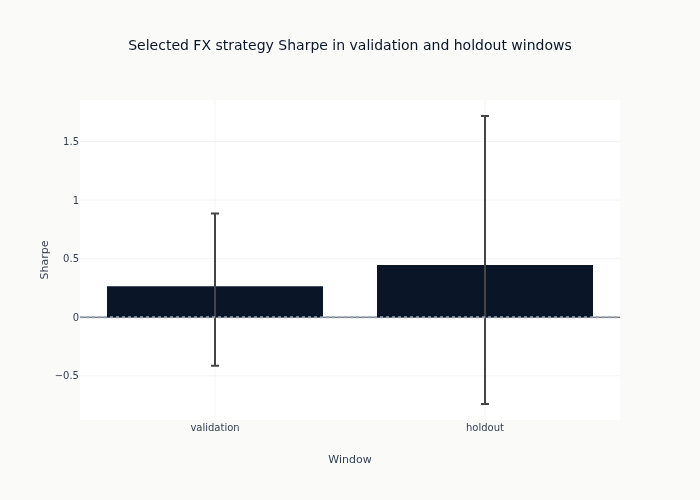

In [14]:
performance_figure = px.bar(
    selected_performance,
    x="period",
    y="sharpe",
    error_y=selected_performance.get_column("sharpe_ci95_hi")
    - selected_performance.get_column("sharpe"),
    error_y_minus=selected_performance.get_column("sharpe")
    - selected_performance.get_column("sharpe_ci95_lo"),
    title="Selected FX strategy Sharpe in validation and holdout windows",
    labels={"period": "Window", "sharpe": "Sharpe"},
)
performance_figure.add_hline(y=0, line_dash="dot", line_color=COLORS["recede"])
performance_figure.show()

### Register the cohort and paired evidence this section reads

The bootstrapped comparisons and the effective-rank cohort statistics are computed here rather
than assumed. They used to be a side effect of the holdout lock transaction; with that gone,
the notebook that reads them is the notebook that has to produce them.

The carrier is passed in rather than left to the populator. Left to itself it ranks the
registry on raw Sharpe, which would be a second selector sitting beside `resolve_solvent_carrier`
and the cost sweep - and a raw ranking has no notion of a retired generation, so it would pair
the superseded conformal-v2 backtest and describe a carrier this case study does not report.

In [15]:
_periods_per_year = int(
    yaml.safe_load((get_case_study_dir(CASE_STUDY_ID) / "config" / "setup.yaml").read_text())[
        "evaluation"
    ]["periods_per_year"]
)
# The cohort statistics warn per metric for every cohort whose leader holds a constant position
# - a deflated Sharpe needs return variance and a correlation matrix, and neither is defined
# there. The warnings are collected rather than printed: each one carries the absolute path of
# the module that raised it, which is this machine's path and does not belong in a committed
# notebook. What they mean is a count, so a count is what is reported.
with warnings.catch_warnings(record=True) as _cohort_warnings:
    warnings.simplefilter("always")
    _cohort_counts = compute_and_register(CASE_STUDY_ID, prediction_hashes=ADMITTED_PREDICTIONS)
_undefined = Counter(str(entry.message).split(" for ")[0] for entry in _cohort_warnings)
_paired_rows = populate_paired_metrics(
    CASE_STUDY_ID,
    periods_per_year=_periods_per_year,
    carrier=resolve_canonical_rank1_lineage(CASE_STUDY_ID, admitted=ADMITTED),
    replace_all=True,
)
print(
    f"cohort_metrics: {sum(_cohort_counts[k] for k in ('family', 'stagelabel', 'label'))} rows; "
    f"backtest_paired_metrics: {sum(1 for row in _paired_rows if 'skip' not in row)} pairs"
)
for _metric, _count in sorted(_undefined.items()):
    print(f"  undefined on a constant-position cohort: {_metric} x{_count}")

[cohort_metrics] fx_pairs (ppy=252)


  family: 27 cohorts


    [1/27] family stage=signal label=fwd_ret_1d family=linear leader=042f2cee K=56 K_eff_mp=2.0 K_eff_er=2.178461990701921 dsr_er=-0.03705308043673411 (0.2s)


    [2/27] family stage=allocation label=fwd_ret_1d family=linear leader=0a1d5087 K=48 K_eff_mp=2.0 K_eff_er=1.9820844963034572 dsr_er=-0.041170660690916884 (1.0s)


    [3/27] family stage=signal label=fwd_ret_21d family=linear leader=19cb9db4 K=52 K_eff_mp=2.0 K_eff_er=2.0088207445868584 dsr_er=0.00457070958506681 (0.2s)


...

    + val_rank1_self: sharpe_diff=0.18138946718755822


    + signal_leader: sharpe_diff=0.05418987168986414


    + allocation_leader: sharpe_diff=0.0


    + risk_overlay_leader: sharpe_diff=0.1486274839909631


cohort_metrics: 42 rows; backtest_paired_metrics: 6 pairs
  undefined on a constant-position cohort: unclosed database in <sqlite3.Connection object at 0x7460e003cf40> x1
  undefined on a constant-position cohort: unclosed database in <sqlite3.Connection object at 0x7460e003d3f0> x1
  undefined on a constant-position cohort: unclosed database in <sqlite3.Connection object at 0x7460e003d4e0> x1
  undefined on a constant-position cohort: unclosed database in <sqlite3.Connection object at 0x7460e003d6c0> x1
  undefined on a constant-position cohort: unclosed database in <sqlite3.Connection object at 0x7461089eeb60> x1


In [16]:
holdout_pairs = load_paired_metrics(
    CASE_STUDY_ID,
    challenger_hash=holdout_backtest.hash,
    case_dir=study.root,
)
validation_pairs = load_paired_metrics(
    CASE_STUDY_ID,
    challenger_hash=selected_validation.hash,
    case_dir=study.root,
)
if holdout_pairs.is_empty() or validation_pairs.is_empty():
    raise ValueError("required paired validation or holdout evidence is missing")

validation_to_holdout = holdout_pairs.filter(
    (pl.col("benchmark_hash") == selected_validation.hash)
    & (pl.col("benchmark_kind") == "val_rank1_self")
)
holdout_to_benchmark = holdout_pairs.filter(
    pl.col("benchmark_kind") == "equal_weight_holdout_side_artifact"
)
validation_to_benchmark = validation_pairs.filter(
    pl.col("benchmark_kind") == "equal_weight_side_artifact"
)
paired_required = {
    "sharpe_diff",
    "sharpe_diff_ci95_lo",
    "sharpe_diff_ci95_hi",
    "ret_diff",
    "ret_diff_ci95_lo",
    "ret_diff_ci95_hi",
    "prob_challenger_wins",
    "p_value",
}
paired_rows = []
for comparison, frame in (
    ("holdout minus validation", validation_to_holdout),
    ("holdout minus equal weight", holdout_to_benchmark),
    ("validation minus equal weight", validation_to_benchmark),
):
    if frame.height != 1 or not paired_required <= set(frame.columns):
        raise ValueError(f"missing required paired comparison: {comparison}")
    values = frame.row(0, named=True)
    if any(values[name] is None or not np.isfinite(values[name]) for name in paired_required):
        raise ValueError(f"non-finite paired comparison: {comparison}")
    paired_rows.append(
        {
            "comparison": comparison,
            **{name: values[name] for name in paired_required},
        }
    )
paired_evidence = pl.DataFrame(paired_rows)
paired_evidence

comparison,ret_diff_ci95_hi,sharpe_diff,sharpe_diff_ci95_hi,ret_diff_ci95_lo,p_value,sharpe_diff_ci95_lo,ret_diff,prob_challenger_wins
str,f64,f64,f64,f64,f64,f64,f64,f64
"""holdout minus validation""",0.073236,0.181389,1.507064,-0.059197,0.783,-1.166658,0.009292,0.641
"""holdout minus equal weight""",0.021864,-0.466877,0.221281,-0.040696,0.2025,-1.215899,-0.008928,0.0955
"""validation minus equal weight""",0.031843,0.038743,0.582456,-0.019145,0.896,-0.513284,0.0039,0.546


## Return and drawdown paths

Each window compounds its own daily returns from initial wealth. The plot does not concatenate the
disjoint validation and holdout calendars.

/tmp/ipykernel_3594834/3188021677.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


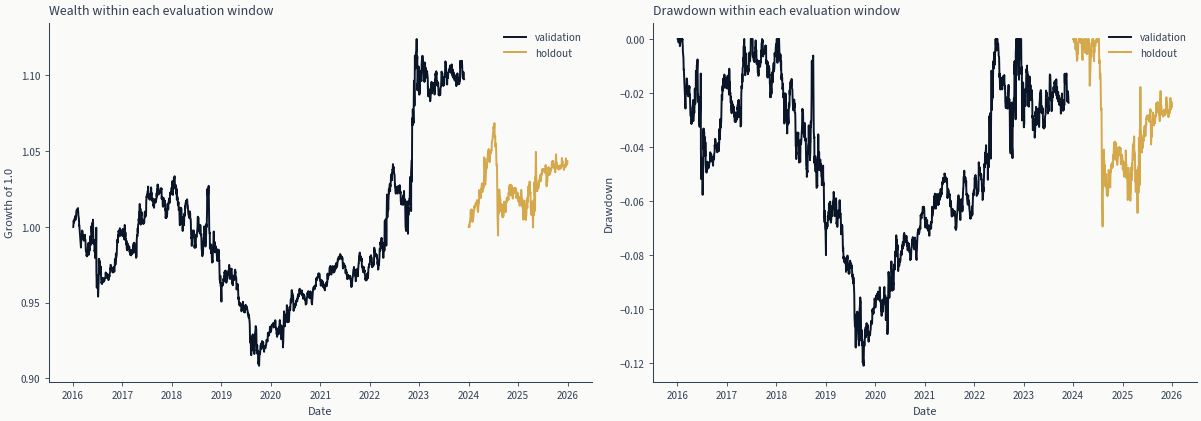

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for period, result in (("validation", selected_validation), ("holdout", holdout_backtest)):
    paths = [path for path in result.artifacts() if path.name == "daily_returns.parquet"]
    if len(paths) != 1:
        raise ValueError(f"{result.hash} must have one daily return artifact")
    returns = pl.read_parquet(paths[0]).select("timestamp", "daily_return").sort("timestamp")
    if returns.get_column("timestamp").n_unique() != returns.height:
        raise ValueError(f"{result.hash} repeats a return timestamp")
    values = returns.get_column("daily_return").to_numpy()
    wealth = np.cumprod(1.0 + values)
    drawdown = wealth / np.maximum.accumulate(wealth) - 1.0
    dates = returns.get_column("timestamp").to_list()
    axes[0].plot(dates, wealth, label=period)
    axes[1].plot(dates, drawdown, label=period)

axes[0].set_title("Wealth within each evaluation window")
axes[0].set_ylabel("Growth of 1.0")
axes[1].set_title("Drawdown within each evaluation window")
axes[1].set_ylabel("Drawdown")
for axis in axes:
    axis.set_xlabel("Date")
    axis.legend(frameon=False)
# No `tight_layout` here: matplotlibrc sets `figure.constrained_layout.use`, so the figure
# already has a layout engine and asking for a second one warns. The warning names the
# kernel's own temporary module path, which then lands in the committed notebook and fails
# the output-hygiene guard.
fig.show()

## Result interpretation

The sentences below are computed from the registered metrics. An interval wholly above or below zero
is reported as such; an interval spanning zero is not converted into a positive or negative claim.

In [18]:


def _interval_read(name: str, point: float, lower: float, upper: float) -> str:
    if lower > 0:
        status = "its interval is above zero"
    elif upper < 0:
        status = "its interval is below zero"
    else:
        status = "its interval includes zero"
    return f"{name}: {point:.3f} [{lower:.3f}, {upper:.3f}]; {status}."


validation_row = selected_performance.filter(pl.col("period") == "validation").row(0, named=True)
holdout_row = selected_performance.filter(pl.col("period") == "holdout").row(0, named=True)
decay_row = paired_evidence.filter(pl.col("comparison") == "holdout minus validation").row(
    0, named=True
)

interpretation = pl.DataFrame(
    {
        "evidence": ["validation", "holdout", "holdout change"],
        "reading": [
            _interval_read(
                "Validation Sharpe",
                validation_row["sharpe"],
                validation_row["sharpe_ci95_lo"],
                validation_row["sharpe_ci95_hi"],
            ),
            _interval_read(
                "Holdout Sharpe",
                holdout_row["sharpe"],
                holdout_row["sharpe_ci95_lo"],
                holdout_row["sharpe_ci95_hi"],
            ),
            _interval_read(
                "Holdout minus validation Sharpe",
                decay_row["sharpe_diff"],
                decay_row["sharpe_diff_ci95_lo"],
                decay_row["sharpe_diff_ci95_hi"],
            ),
        ],
    }
)
interpretation

evidence,reading
str,str
"""validation""","""Validation Sharpe: 0.264 [-0.4…"
"""holdout""","""Holdout Sharpe: 0.445 [-0.741,…"
"""holdout change""","""Holdout minus validation Sharp…"


## Key takeaways

- The immutable candidate set determines the exact selected configuration, and the holdout
  lineage follows from it rather than being recorded alongside it.
- Controlled cost and risk evidence changes one strategy field at a time.
- The holdout cannot cause reselection, because the selection is upstream of it and frozen.
- All result-specific interpretation is produced from the registered artifacts this notebook
  resolved, so a re-run reports the same numbers or fails.